# Analisis estadistico del benchmark de colors

Este notebook analiza el experimento principal con imagenes con ruido (`recollida-dades/experiments/soroll/csv/sample-colors_4o.csv`). La respuesta es `error_cromatic`, el factor principal es `model` y la covariable cuantitativa es `chroma`.

Como cada imagen se evalua con los dos modelos, la comparacion principal se hace como muestra apareada: para cada `image_name` calculamos `D = error_gpt_4o_mini - error_gpt_4o`.

## Configuracion

Limpiamos el entorno, cargamos librerias y definimos rutas relativas para que el notebook funcione tanto desde la raiz del repo como desde la carpeta `analisis/`.

In [12]:
cell_start <- Sys.time()

format_duration <- function(seconds) {
  seconds <- max(0, as.numeric(seconds))
  if (seconds < 60) return(sprintf("%.1fs", seconds))
  minutes <- floor(seconds / 60)
  remaining_seconds <- seconds %% 60
  if (minutes < 60) return(sprintf("%dm %04.1fs", minutes, remaining_seconds))
  hours <- floor(minutes / 60)
  remaining_minutes <- minutes %% 60
  sprintf("%dh %dm %04.1fs", hours, remaining_minutes, remaining_seconds)
}

print_cell_time <- function(start_time) {
  elapsed <- as.numeric(difftime(Sys.time(), start_time, units = "secs"))
  cat("Temps cel.la:", format_duration(elapsed), "\n")
}

rm(list = setdiff(ls(), c("format_duration", "print_cell_time", "cell_start")))

suppressPackageStartupMessages(library(tidyverse))

analysis_dir <- if (dir.exists("analisis")) file.path(".", "analisis") else "."
data_root <- if (dir.exists("recollida-dades")) "." else ".."

csv_dir <- file.path(data_root, "recollida-dades", "experiments", "soroll", "csv")
scripts_dir <- file.path(analysis_dir, "scripts")
final_path <- file.path(csv_dir, "sample-colors_4o.csv")
N_CHROMA_GROUPS <- 4

print_cell_time(cell_start)


Temps cel.la: 0.0s 


## Carga de funciones

Cargamos las funciones de `analisis/scripts`. Si falta alguna funcion critica, paramos para no interpretar resultados incompletos.

In [13]:
cell_start <- Sys.time()

script_files <- list.files(scripts_dir, pattern = "\\.R$", full.names = TRUE)
walk(script_files, source)

required_functions <- c(
  "prepare_benchmark_data",
  "validate_paired_design",
  "create_paired_errors",
  "descriptive_by_model",
  "paired_ttest_summary",
  "fit_error_chroma_models",
  "summarise_error_chroma_models",
  "linear_model_summary",
  "plot_error_distribution",
  "plot_error_boxplot",
  "plot_paired_difference_qq",
  "plot_paired_difference_histogram",
  "plot_error_vs_chroma",
  "plot_difference_vs_chroma",
  "plot_lm_diagnostics",
  "add_chroma_groups",
  "summarise_chroma_groups",
  "summarise_paired_chroma_groups",
  "paired_ttest_by_chroma_group",
  "plot_error_by_chroma_group",
  "plot_difference_by_chroma_group"
)
missing_functions <- setdiff(required_functions, ls())
if (length(missing_functions) > 0) {
  stop(paste("Error: faltan funciones:", paste(missing_functions, collapse = ", ")))
}

print_cell_time(cell_start)


Temps cel.la: 0.0s 


## Carga y validacion de datos

Usamos solo el CSV final del experimento con ruido. Filtramos respuestas validas (`status == "ok"`) y comprobamos que el diseno apareado esta completo: 1000 imagenes, dos modelos y una observacion por imagen y modelo.

In [14]:
cell_start <- Sys.time()

if (!file.exists(final_path)) {
  stop(paste("No se ha encontrado el CSV final:", final_path))
}

raw_data <- read_csv(final_path, show_col_types = FALSE)
analysis_data <- prepare_benchmark_data(raw_data)
paired_data <- create_paired_errors(analysis_data)
analysis_data_grouped <- add_chroma_groups(analysis_data, N_CHROMA_GROUPS)
paired_data_grouped <- add_chroma_groups(paired_data, N_CHROMA_GROUPS)

checks <- tibble(
  check = c(
    "filas CSV original",
    "imagenes unicas CSV original",
    "modelos CSV original",
    "filas validas para analisis",
    "NA en error_cromatic tras filtrar",
    "filas tabla apareada",
    "grupos de chroma"
  ),
  value = c(
    nrow(raw_data),
    n_distinct(raw_data$image_name),
    n_distinct(raw_data$model),
    nrow(analysis_data),
    sum(is.na(analysis_data$error_cromatic)),
    nrow(paired_data),
    n_distinct(paired_data_grouped$chroma_group)
  )
)

print(checks)

stopifnot(nrow(raw_data) == 2000)
stopifnot(n_distinct(raw_data$image_name) == 1000)
stopifnot(n_distinct(raw_data$model) == 2)
stopifnot(sum(is.na(analysis_data$error_cromatic)) == 0)
stopifnot(nrow(paired_data) == 1000)
stopifnot(n_distinct(paired_data_grouped$chroma_group) == N_CHROMA_GROUPS)

print_cell_time(cell_start)


# A tibble: 7 × 2
  check                             value
  <chr>                             <int>
1 filas CSV original                 2000
2 imagenes unicas CSV original       1000
3 modelos CSV original                  2
4 filas validas para analisis        2000
5 NA en error_cromatic tras filtrar     0
6 filas tabla apareada               1000
7 grupos de chroma                      4
Temps cel.la: 0.2s 


## Descriptiva

Primero describimos `error_cromatic` por modelo. Esta tabla resume la magnitud del error antes de entrar en inferencia.

In [15]:
cell_start <- Sys.time()

descriptive_table <- descriptive_by_model(analysis_data) |>
  mutate(across(where(is.numeric), ~ round(.x, 3)))

print(descriptive_table)

print_cell_time(cell_start)


# A tibble: 2 × 10
  model           n  mean median    sd    q1    q3   iqr   min   max
  <chr>       <dbl> <dbl>  <dbl> <dbl> <dbl> <dbl> <dbl> <dbl> <dbl>
1 gpt-4o       1000  35.1   30.4  22.2  19.5  44.5  24.9  1.41  132.
2 gpt-4o-mini  1000  60.7   54.8  33.5  35.1  79.6  44.5  4     186.
Temps cel.la: 0.0s 


## Graficos descriptivos del error

La distribucion y el boxplot ayudan a ver si un modelo tiende a concentrar errores menores y si hay colas o valores extremos.

Warning message in ggplot2::geom_boxplot(alpha = 0.75, outlier_alpha = 0.35):
"Ignoring unknown parameters: `outlier_alpha`"


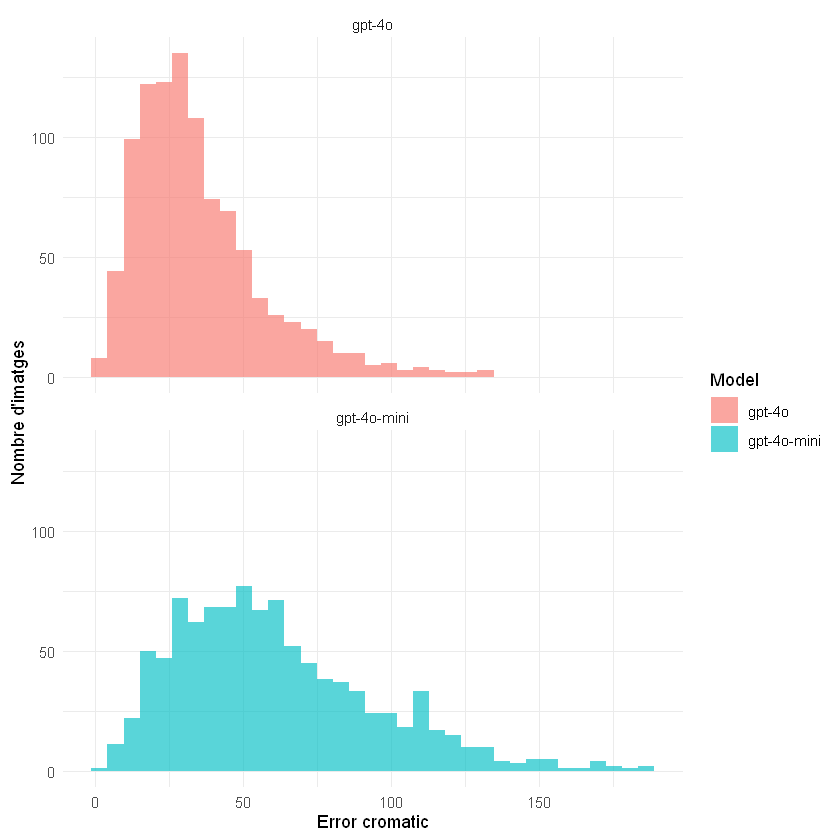

Temps cel.la: 0.5s 


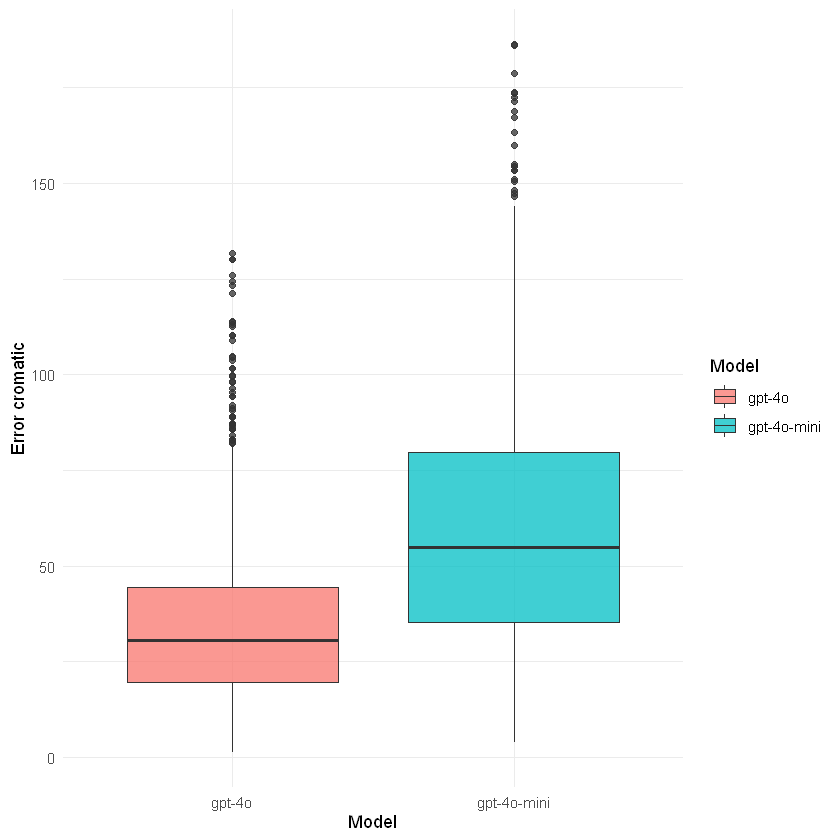

In [16]:
cell_start <- Sys.time()

plot_error_distribution(analysis_data)
plot_error_boxplot(analysis_data)

print_cell_time(cell_start)


## Comparacion apareada entre modelos

Definimos `D = error_gpt_4o_mini - error_gpt_4o`. Si el intervalo de confianza de `D` queda por encima de 0, entonces `gpt-4o-mini` tiene mas error medio que `gpt-4o` en las mismas imagenes.

In [17]:
cell_start <- Sys.time()

paired_summary <- paired_ttest_summary(paired_data) |>
  mutate(across(where(is.numeric), ~ signif(.x, 5)))

print(paired_summary)

paired_test <- t.test(paired_data$error_gpt_4o_mini, paired_data$error_gpt_4o, paired = TRUE)
print(paired_test)

if (paired_test$conf.int[1] > 0 && paired_test$conf.int[2] > 0) {
  cat("Interpretacion: el IC 95% queda por encima de 0; gpt-4o-mini tiene mas error medio que gpt-4o.\n")
} else if (paired_test$conf.int[1] < 0 && paired_test$conf.int[2] < 0) {
  cat("Interpretacion: el IC 95% queda por debajo de 0; gpt-4o-mini tiene menos error medio que gpt-4o.\n")
} else {
  cat("Interpretacion: el IC 95% incluye 0; no se descarta igualdad de errores medios.\n")
}

print_cell_time(cell_start)


# A tibble: 1 × 8
      n mean_D  sd_D conf_low conf_high     t    df  p_value
  <dbl>  <dbl> <dbl>    <dbl>     <dbl> <dbl> <dbl>    <dbl>
1  1000   25.6  34.4     23.5      27.7  23.5   999 1.29e-97

	Paired t-test

data:  paired_data$error_gpt_4o_mini and paired_data$error_gpt_4o
t = 23.508, df = 999, p-value < 2.2e-16
alternative hypothesis: true mean difference is not equal to 0
95 percent confidence interval:
 23.46027 27.73370
sample estimates:
mean difference 
       25.59698 

Interpretacion: el IC 95% queda por encima de 0; gpt-4o-mini tiene mas error medio que gpt-4o.
Temps cel.la: 0.0s 


## Validacion grafica del t-test apareado

Para el t-test apareado se estudia la normalidad de la diferencia `D`. Con `n = 1000`, el Teorema Central del Limite hace razonable la inferencia sobre la media aunque la distribucion no sea perfectamente normal, pero igualmente revisamos histograma y QQ-plot.

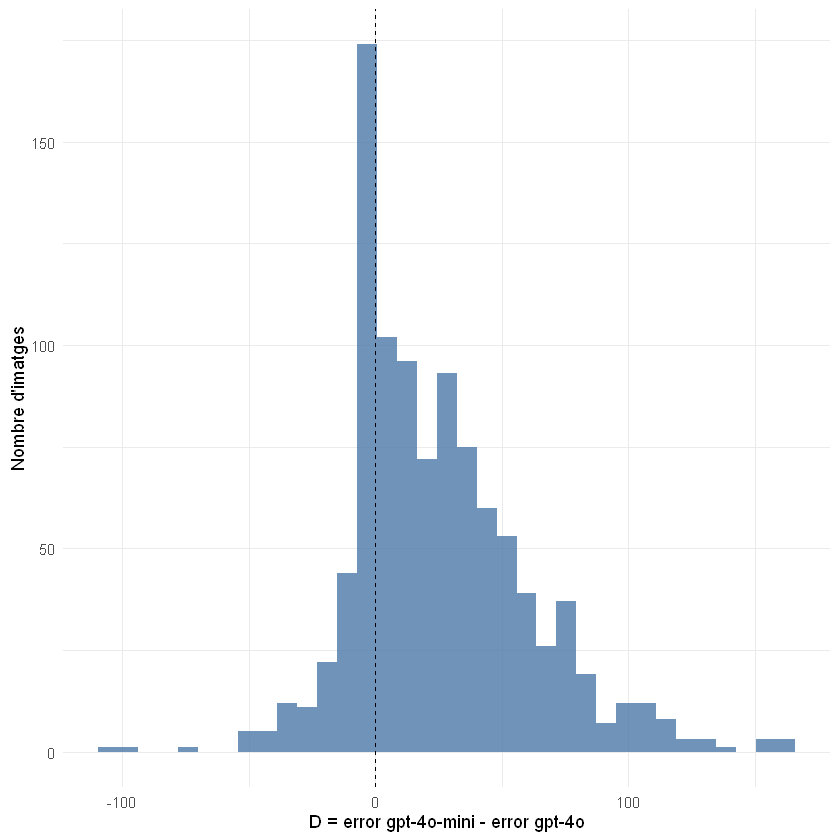

Temps cel.la: 0.3s 


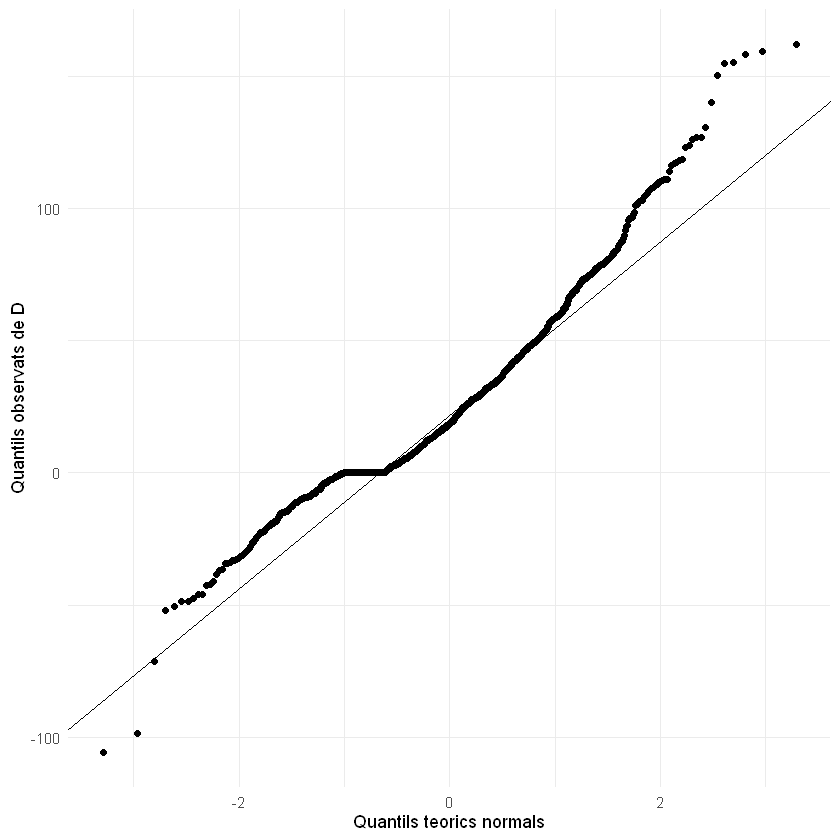

In [18]:
cell_start <- Sys.time()

plot_paired_difference_histogram(paired_data)
plot_paired_difference_qq(paired_data)

print_cell_time(cell_start)


## Relacion entre error y chroma

Estudiamos si el error cromatico se asocia con el `chroma`. Primero lo miramos por modelo, y despues analizamos si la diferencia apareada `D` cambia con `chroma`.

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


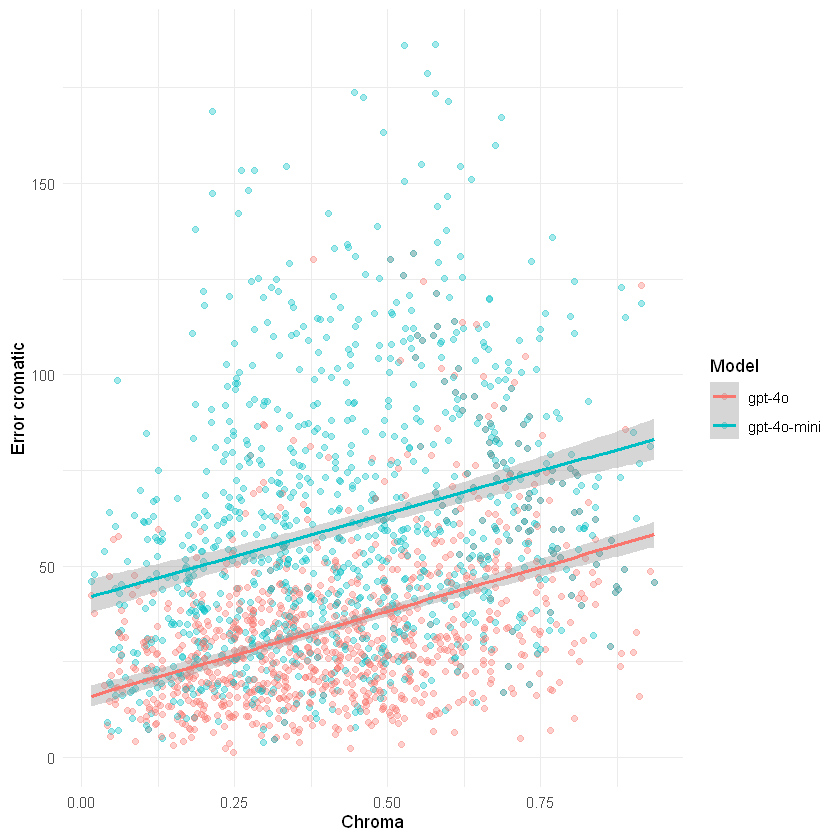

Temps cel.la: 0.5s 


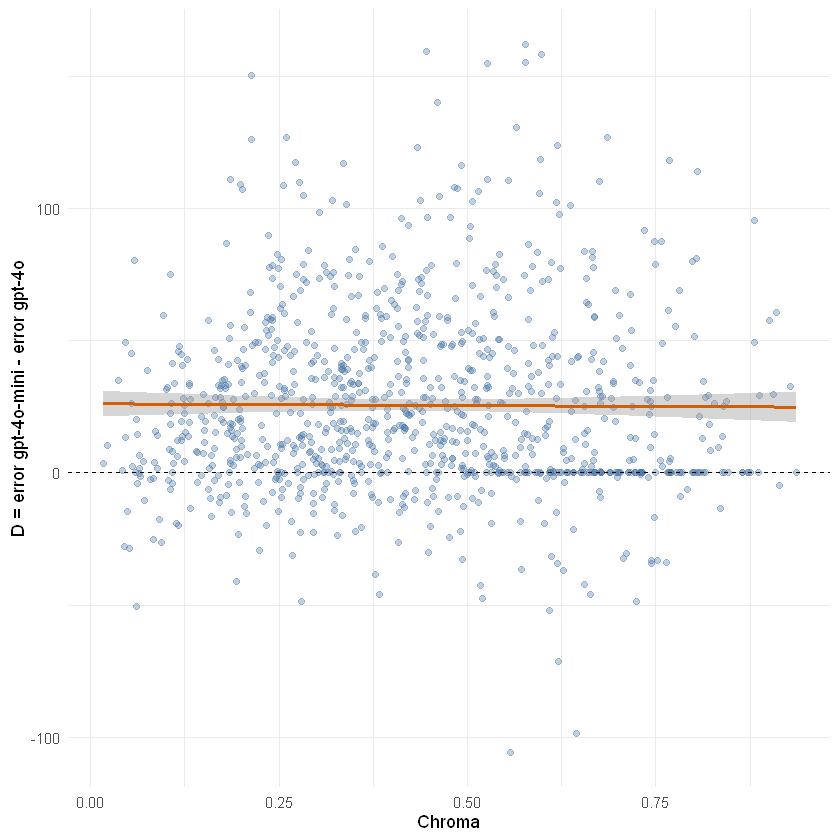

In [19]:
cell_start <- Sys.time()

plot_error_vs_chroma(analysis_data)
plot_difference_vs_chroma(paired_data)

print_cell_time(cell_start)


## Chroma agrupado

Agrupamos `chroma` en 4 grupos por cuantiles (`G1` bajo chroma, `G4` alto chroma). Esto no es un test nuevo sobre la desviacion: es una forma descriptiva e inferencial sencilla de ver si el error y la diferencia apareada cambian segun el nivel de chroma. Uso grupos por cuantiles en vez de `kmeans` porque en una variable unidimensional son mas faciles de justificar y tienen tamanos parecidos.

In [20]:
cell_start <- Sys.time()

chroma_summary <- summarise_chroma_groups(analysis_data_grouped) |>
  mutate(across(where(is.numeric), ~ round(.x, 3)))

paired_chroma_summary <- summarise_paired_chroma_groups(paired_data_grouped) |>
  mutate(across(where(is.numeric), ~ round(.x, 3)))

paired_chroma_tests <- paired_ttest_by_chroma_group(paired_data_grouped) |>
  mutate(across(where(is.numeric), ~ signif(.x, 5)))

cat("Resumen de error por grupo de chroma y modelo:
")
print(chroma_summary)

cat("
Resumen apareado por grupo de chroma:
")
print(paired_chroma_summary)

cat("
T-test apareado dentro de cada grupo de chroma:
")
print(paired_chroma_tests)

print_cell_time(cell_start)


Resumen de error por grupo de chroma y modelo:
# A tibble: 8 × 9
  chroma_group model           n chroma_min chroma_max mean_error median_error
  <fct>        <chr>       <dbl>      <dbl>      <dbl>      <dbl>        <dbl>
1 G1           gpt-4o        250      0.016      0.271       24.1         22.5
2 G1           gpt-4o-mini   250      0.016      0.271       47.2         42.8
3 G2           gpt-4o        250      0.271      0.419       30.3         27.6
4 G2           gpt-4o-mini   250      0.271      0.419       57.6         51.5
5 G3           gpt-4o        250      0.419      0.59        35.9         29.8
6 G3           gpt-4o-mini   250      0.419      0.59        67.6         59.4
7 G4           gpt-4o        250      0.592      0.936       50.2         47.9
8 G4           gpt-4o-mini   250      0.592      0.936       70.4         65.3
# ℹ 2 more variables: sd_error <dbl>, iqr_error <dbl>

Resumen apareado por grupo de chroma:
# A tibble: 4 × 9
  chroma_group     n chroma_min ch

## Graficos por grupo de chroma

Los boxplots permiten comparar tanto el error absoluto de cada modelo como la diferencia apareada `D` dentro de cada grupo de chroma.

In [ ]:
cell_start <- Sys.time()

plot_error_by_chroma_group(analysis_data_grouped)
plot_difference_by_chroma_group(paired_data_grouped)

print_cell_time(cell_start)


## Modelos lineales

Ajustamos `lm(error_cromatic ~ chroma)` por separado para cada modelo y `lm(D ~ chroma)` para la diferencia apareada. El coeficiente de `chroma` indica el cambio esperado en el error al aumentar una unidad de chroma, y `R2` resume cuanta variabilidad explica el modelo lineal.

In [9]:
cell_start <- Sys.time()

error_chroma_models <- fit_error_chroma_models(analysis_data)
difference_chroma_model <- lm(D ~ chroma, data = paired_data)
difference_chroma_group_model <- lm(D ~ chroma_group, data = paired_data_grouped)

lm_error_chroma_table <- summarise_error_chroma_models(error_chroma_models)
lm_difference_table <- linear_model_summary(difference_chroma_model, "D = mini - gpt-4o")
lm_difference_group_table <- linear_model_summary(difference_chroma_group_model, "D ~ grupos de chroma")

lm_table <- bind_rows(lm_error_chroma_table, lm_difference_table, lm_difference_group_table) |>
  mutate(across(where(is.numeric), ~ signif(.x, 5)))

print(lm_table)

print_cell_time(cell_start)


# A tibble: 6 × 9
  model         term  estimate std_error      t  p_value r_squared adj_r_squared
  <chr>         <chr>    <dbl>     <dbl>  <dbl>    <dbl>     <dbl>         <dbl>
1 gpt-4o        (Int…    15.3       1.48 10.3   8.51e-24 0.181          0.180   
2 gpt-4o        chro…    45.9       3.09 14.8   3.71e-45 0.181          0.180   
3 gpt-4o-mini   (Int…    41.5       2.37 17.5   8.76e-60 0.0748         0.0739  
4 gpt-4o-mini   chro…    44.6       4.96  8.98  1.30e-18 0.0748         0.0739  
5 D = mini - g… (Int…    26.2       2.54 10.3   8.85e-24 0.0000639     -0.000938
6 D = mini - g… chro…    -1.34      5.30 -0.253 8.01e- 1 0.0000639     -0.000938
# ℹ 1 more variable: residual_sd <dbl>
Temps cel.la: 0.1s 


## Validacion grafica de modelos lineales

Segun los apuntes, revisamos linealidad y homoscedasticidad con residuos vs predicciones, normalidad con QQ-plot e histograma, e independencia observando residuos en el orden de las observaciones.

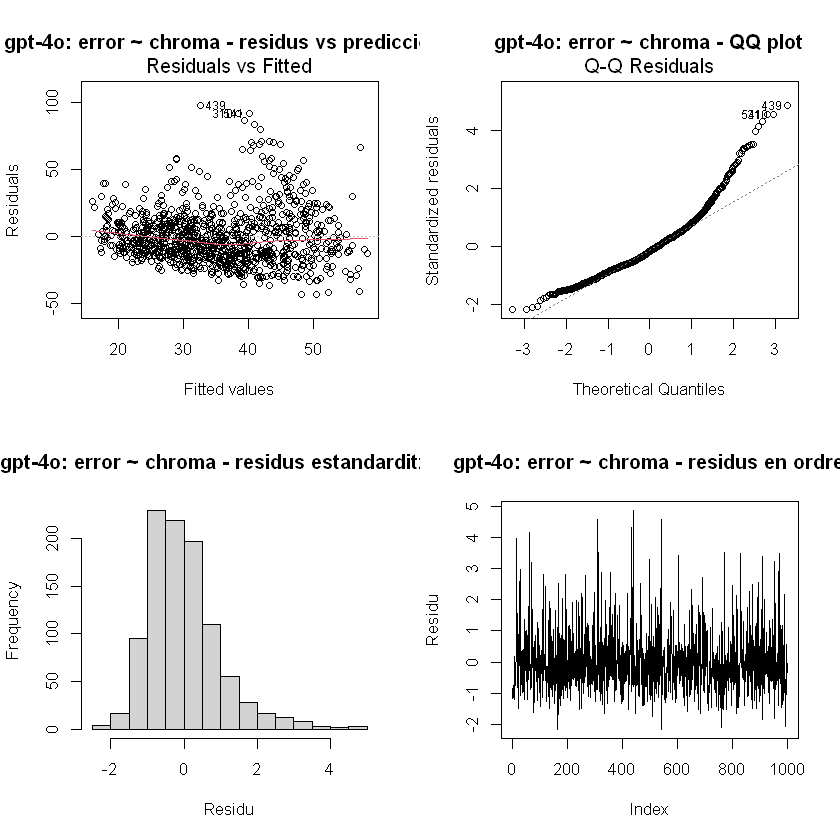

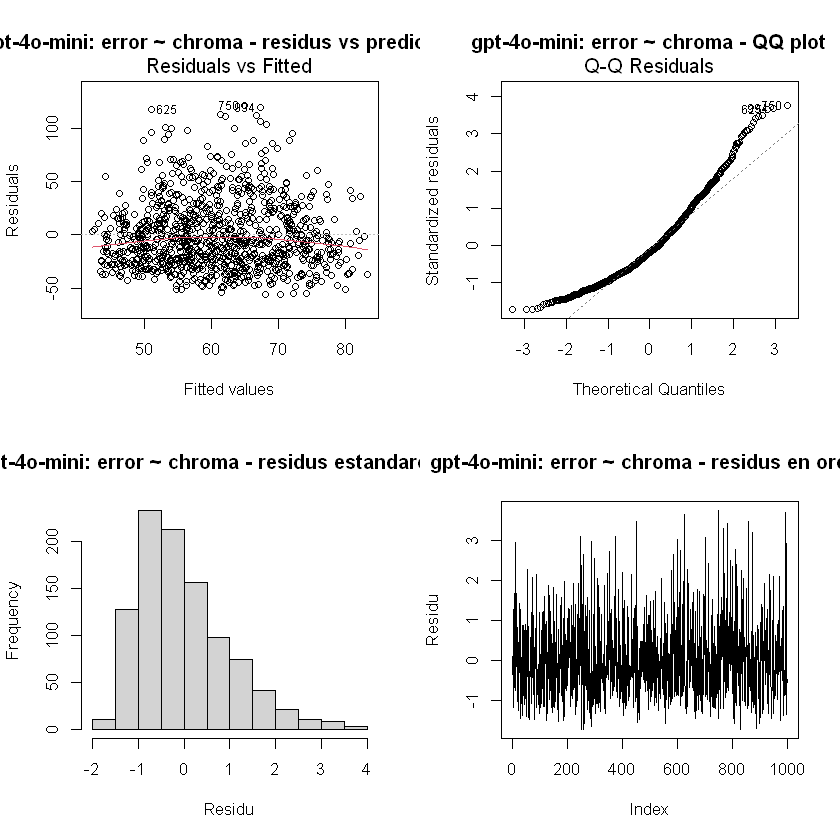

Temps cel.la: 0.2s 


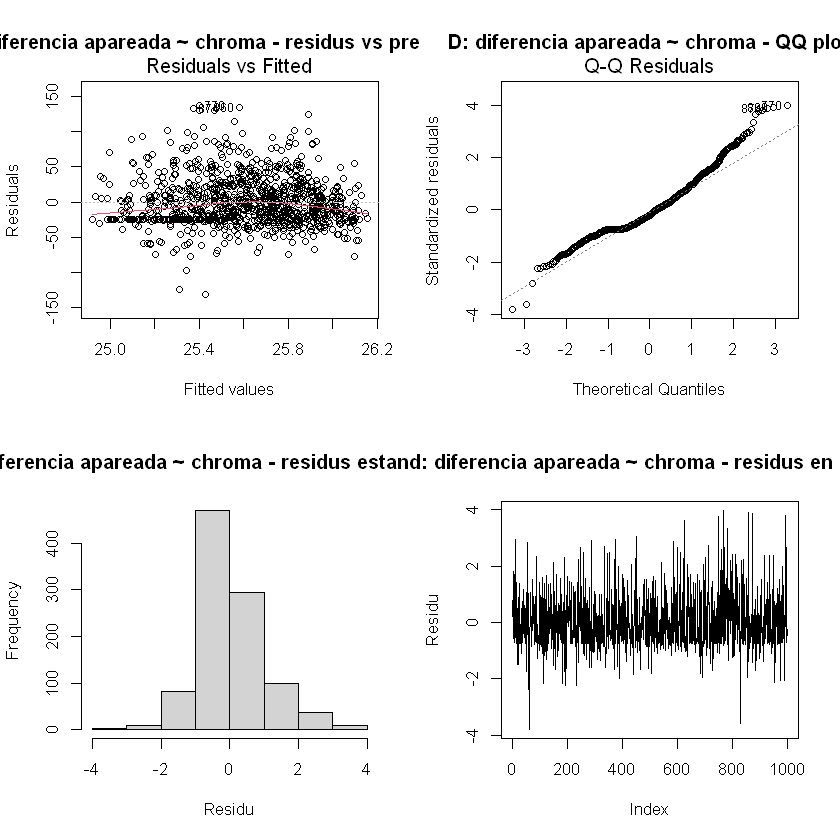

In [10]:
cell_start <- Sys.time()

plot_lm_diagnostics(error_chroma_models[["gpt-4o"]], "gpt-4o: error ~ chroma")
plot_lm_diagnostics(error_chroma_models[["gpt-4o-mini"]], "gpt-4o-mini: error ~ chroma")
plot_lm_diagnostics(difference_chroma_model, "D: diferencia apareada ~ chroma")
plot_lm_diagnostics(difference_chroma_group_model, "D: diferencia apareada ~ grupo chroma")

print_cell_time(cell_start)


## Resumen para el informe

Esta celda deja redactadas las frases numericas principales. La seccion de resultados del informe puede usar estas salidas sin copiar todos los decimales que imprime R.

In [11]:
cell_start <- Sys.time()

mean_gpt4o <- descriptive_by_model(analysis_data) |> filter(model == "gpt-4o") |> pull(mean)
mean_mini <- descriptive_by_model(analysis_data) |> filter(model == "gpt-4o-mini") |> pull(mean)
mean_D <- mean(paired_data$D)
ci_D <- paired_test$conf.int
p_value <- paired_test$p.value
r2_D <- summary(difference_chroma_model)$r.squared
slope_D <- coef(difference_chroma_model)[["chroma"]]
top_chroma_group <- paired_chroma_summary |> arrange(desc(mean_D)) |> slice(1)

cat(sprintf("Error medio gpt-4o: %.2f\n", mean_gpt4o))
cat(sprintf("Error medio gpt-4o-mini: %.2f\n", mean_mini))
cat(sprintf("D media (mini - gpt-4o): %.2f\n", mean_D))
cat(sprintf("IC 95%% de D: [%.2f, %.2f]\n", ci_D[1], ci_D[2]))
cat(sprintf("p-valor del t-test apareado: %.3g\n", p_value))
cat(sprintf("Pendiente de chroma sobre D: %.2f\n", slope_D))
cat(sprintf("R2 del modelo D ~ chroma: %.3f\n", r2_D))
cat(sprintf("Grupo de chroma con D media mas alta: %s (D = %.2f)\n", top_chroma_group$chroma_group, top_chroma_group$mean_D))

print_cell_time(cell_start)


Error medio gpt-4o: 35.11
Error medio gpt-4o-mini: 60.71
D media (mini - gpt-4o): 25.60
IC 95% de D: [23.46, 27.73]
p-valor del t-test apareado: 1.29e-97
Pendiente de chroma sobre D: -1.34
R2 del modelo D ~ chroma: 0.000
Temps cel.la: 0.0s 
